In [2]:
import pandas as pd
import pandas
import numpy as np
import matplotlib.pyplot as matpyplot
from collections import Counter

In [3]:
# from sklearn.model_selection import train_test_split
# import sklearn as skl
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score

Wir deklarieren die entsprechenden 10 Kategorien für unseren Fashion-MNSIT Trainingsdatensatz

In [4]:
LABELS = {
    0: "T-Shirt/Oberteil",
    1: "Hose",
    2: "Pullover",
    3: "Kleid",
    4: "Mantel",
    5: "Sandale",
    6: "Hemd",
    7: "Sneaker",
    8: "Tasche",
    9: "Stiefelette"
}

Wir importieren den Datensatz und geben einen kleinen Auschnitt zur Probe aus

In [5]:
bsp = pd.read_csv("fashion-mnist_train.csv", nrows=10)
bsp.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


( Wir möchten nun gucken, ob wir die Bilder richtig visualisieren können.

Streng genommen bringt dieser Schritt unserem Modell nichts.

Er wird für unser Verständnis aber trotzdem vom Vorteil sein. )


In [6]:
zeile = bsp.iloc[1]         # nimmt die zweite Zeile, also die erste mit kommagetrennten Zahlen
label = zeile.iloc[0]       # nimmt den ersten Wert dieser Spalte, also das Label, welcher Klasse das Kleidungsstück angehört
pixel = zeile.iloc[1:]      # die restlichen 784 kommagetrennten Graustufenwerte [0 bis 255]

Visuelle Ausgabe der kommagetrennten Graustufenwerte als Bild

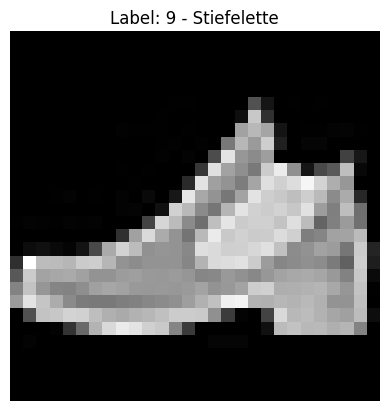

In [7]:
bild = np.array(zeile[1:], dtype=np.uint8).reshape(28,28)         # Um das Bild visualisieren zu können, wandeln wir es in ein 28*28 Array um.
matpyplot.imshow(bild, cmap='gray')
matpyplot.axis("off")
matpyplot.title(f"Label: {label} - {LABELS[label]}")
matpyplot.show()

Nun möchten wir das Bild in 16 Farbgruppen mit je 16 Graustufen unterteilen ~> {{0, ... , 15}, ... , {240, ... , 255}}

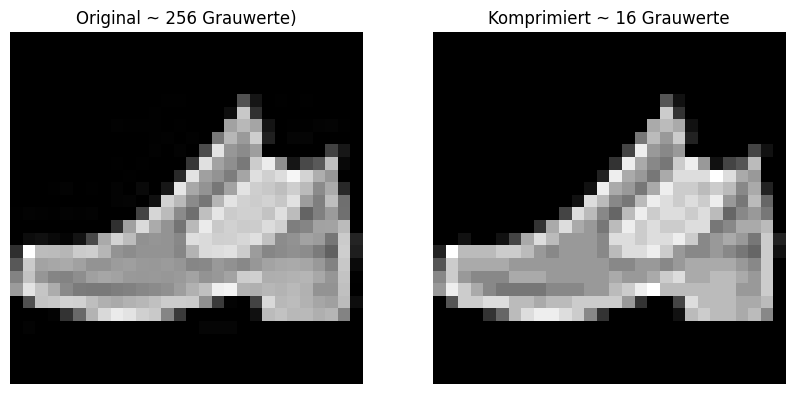

In [8]:
# Dieser Codeblock wurde mit KI generiert
bild_transformed = (bild / 16).astype(np.uint8)
fig, axes = matpyplot.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(bild, cmap='gray', vmin=0, vmax=255)
axes[0].axis("off")
axes[0].set_title(f"Original ~ 256 Grauwerte)")
axes[1].imshow(bild_transformed, cmap='gray', vmin=0, vmax=15)
axes[1].axis("off")
axes[1].set_title("Komprimiert ~ 16 Grauwerte")
matpyplot.show()

Wir sehen also, wenn auch nur an einem Beispiel, das wird das Bild anscheinend fast verlustfrei, komprimieren können. Das machen wir natürlich nicht um Speicherplatz zu sparen, denn das Bild ist bereits sehr klein. Aber dadurch können wir den Rechenaufwand beim Ausführen der Random Trees drastisch reduzieren. Noch enormere Auswirkungen dürfte diese Gruppierung allerdings für andere Klassifikationsmethoden haben.

---

Nun kommen wir zum Klassifikationsteil, also der Lösung des ursprünglichen Problems

---

Wir definieren hier die Funktion um die Pixel in die 16 Gruppen der Graustufen einzuordnen

In [9]:
def group_16(data):
    data.iloc[:, 1:] = (data.iloc[:, 1:] // 16).astype(int)
    return data

In [10]:
group_16(bsp)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0


In [11]:
def bootstrap(data, rows):
    return data.sample(n = rows, replace = True)

In [12]:
bootstrap(bsp, 10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
train = pd.read_csv("fashion-mnist_train.csv")
train = group_16(train)
xTrain = train.iloc[:, 1:]    # wählt alle (784) kommagetrennten Werte außer dem ersten aus.
yTrain = train.iloc[:, 0]     # wählt nur die Klassifikationsziffer aus.

test = pd.read_csv("fashion-mnist_test.csv")
test = group_16(test)
xTest = test.iloc[:, 1:]    # wählt alle (784) kommagetrennten Werte außer dem ersten aus.
yTest = test.iloc[:, 0]     # wählt nur die Klassifikationsziffer aus.

In [14]:
#counts = yTrain.value_counts().reindex(range(10), fill_value=0)
#result_vector = counts.values
#print(result_vector)

---
Random Forest
---
---


In [15]:
B_trees = 100  # Anzahl der Bäume
m_features = int(np.sqrt(xTrain.shape[1]))  # Ist als HYPERPARAMETER Standardmäßig die Wurzel der Features, da wir 28*28 haben also = 28
n_trainDataSets = xTrain.shape[0]  # Anzahl der ausgewerteten Datensätze

trees = []

### Todo

In [16]:
def gini(y):
    counts = np.bincount(y)
    probs = counts / len(y)
    return 1.0 - np.sum(probs ** 2)


def majority_class(y):
    return Counter(y).most_common(1)[0][0]

In [17]:
class TreeNode:
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.prediction = None

In [18]:
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

In [19]:
    def best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = 0
        best_feature, best_threshold = None, None

        parent_gini = gini(y)

        features = np.arange(n_features)
        if self.max_features is not None:
            features = np.random.choice(
                n_features,
                self.max_features,
                replace=False
            )

        for feature in features:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                gain = parent_gini - (
                    len(y_left) / n_samples * gini(y_left)
                    + len(y_right) / n_samples * gini(y_right)
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

In [20]:
def best_split(self, X, y):
    n_samples, n_features = X.shape
    best_gain = 0
    best_feature, best_threshold = None, None

    parent_gini = gini(y)

    features = np.arange(n_features)
    if self.max_features is not None:
        features = np.random.choice(
            n_features, self.max_features, replace=False
        )

    for feature in features:
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            y_left = y[left_mask]
            y_right = y[right_mask]

            gain = parent_gini - (
                len(y_left) / n_samples * gini(y_left)
                + len(y_right) / n_samples * gini(y_right)
            )

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold

In [21]:
def build_tree(self, X, y, depth):
    node = TreeNode()

    if (
        depth >= self.max_depth
        or len(y) < self.min_samples_split
        or len(np.unique(y)) == 1
    ):
        node.prediction = majority_class(y)
        return node

    feature, threshold = self.best_split(X, y)

    if feature is None:
        node.prediction = majority_class(y)
        return node

    node.feature = feature
    node.threshold = threshold

    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    node.left = self.build_tree(X[left_mask], y[left_mask], depth + 1)
    node.right = self.build_tree(X[right_mask], y[right_mask], depth + 1)

    return node


In [22]:
def fit(self, X, y):
    self.root = self.build_tree(X, y, 0)

def predict_one(self, x, node):
    if node.prediction is not None:
        return node.prediction
    if x[node.feature] <= node.threshold:
        return self.predict_one(x, node.left)
    else:
        return self.predict_one(x, node.right)

def predict(self, X):
    return np.array([self.predict_one(x, self.root) for x in X])


In [23]:
class RandomForest:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        max_features = int(np.sqrt(n_features))

        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=max_features
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

    def predict(self, X):
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.array([
            Counter(all_preds[:, i]).most_common(1)[0][0]
            for i in range(X.shape[0])
        ])



In [24]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def class_wise_accuracy(y_true, y_pred, n_classes=10):
    acc = {}
    for c in range(n_classes):
        mask = y_true == c
        acc[c] = np.mean(y_pred[mask] == y_true[mask])
    return acc

In [25]:
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = 0
        best_feature, best_threshold = None, None

        parent_gini = gini(y)

        features = np.arange(n_features)
        if self.max_features is not None:
            features = np.random.choice(
                n_features, self.max_features, replace=False
            )

        for feature in features:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                gain = parent_gini - (
                    len(y_left) / n_samples * gini(y_left)
                    + len(y_right) / n_samples * gini(y_right)
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth):
        node = TreeNode()

        if (
            depth >= self.max_depth
            or len(y) < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            node.prediction = majority_class(y)
            return node

        feature, threshold = self.best_split(X, y)

        if feature is None:
            node.prediction = majority_class(y)
            return node

        node.feature = feature
        node.threshold = threshold

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        node.left = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return node

    def fit(self, X, y):
        self.root = self.build_tree(X, y, 0)

    def predict_one(self, x, node):
        if node.prediction is not None:
            return node.prediction
        if x[node.feature] <= node.threshold:
            return self.predict_one(x, node.left)
        else:
            return self.predict_one(x, node.right)

    def predict(self, X):
        return np.array([self.predict_one(x, self.root) for x in X])


In [26]:
class RandomForest:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        max_features = int(np.sqrt(n_features))

        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=max_features
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

    def predict(self, X):
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.array([
            Counter(all_preds[:, i]).most_common(1)[0][0]
            for i in range(X.shape[0])
        ])


In [27]:
tree = DecisionTree()
print(hasattr(tree, "fit"), hasattr(tree, "predict"))

rf = RandomForest()
print(hasattr(rf, "fit"), hasattr(rf, "predict"))


True True
True True


In [28]:
rf = RandomForest(
    n_estimators=10,
    max_depth=10,
    min_samples_split=5
)
rf.fit(xTrain, yTrain)

yPred = rf.predict(xTest)

print("Overall accuracy:", accuracy(yTest, yPred))

class_acc = class_wise_accuracy(yTest, yPred)
print("Class-wise accuracy:")
for cls, acc in class_acc.items():
    print(f"Class {cls}: {acc:.3f}")

KeyError: "None of [Index([48788, 57060, 21482, 55367, 51341, 10944, 57467,  2267, 27740, 58067,\n       ...\n       31844, 39153, 55948, 54716, 25202, 30569, 30244, 25736, 28412, 48751],\n      dtype='int32', length=60000)] are in the [columns]"